# Extract text (Uno only)

With this notebook we extract only dialogues from pages that likely contain Uno.

In [1]:
model_name = "gemini-2.5-flash-preview-04-17"
thinking_budget = 1024
num_samples = 5

## Compute contiguous dialogues

In [2]:
import glob
import re

pages_analysis = glob.glob(
    "output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/*.json"
)
pages_analysis.sort(
    key=lambda x: float(re.search(r"pkna-([0-9-]+)", x).group(1).replace("-", "."))
)  # type: ignore
pages_analysis[:20]

['output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-0.json',
 'output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-0-2.json',
 'output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-0-3.json',
 'output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-1.json',
 'output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-2.json',
 'output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-3.json',
 'output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-4.json',
 'output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-5.json',
 'output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-6.json',
 'output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-7.json',
 'output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-8.json',
 'output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-9.json',
 'output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430

In [3]:
# Apply overrides
import json
import os

overrides_files = glob.glob("input/overrides/filter/*.json")
filter_overrides = {os.path.basename(f): json.load(open(f)) for f in overrides_files}

filter_overrides

{'pkna-32.json': {'presence_add': [],
  'presence_remove': ['input/pkna/pkna-32/pk00058.jpg']},
 'pkna-19.json': {'presence_add': [],
  'presence_remove': ['input/pkna/pkna-19/PKNA61.jpeg']},
 'pkna-0.json': {'presence_add': [],
  'presence_remove': ['input/pkna/pkna-0/pkna-0-004.jpg',
   'input/pkna/pkna-0/pkna-0-010.jpg',
   'input/pkna/pkna-0/pkna-0-011.jpg',
   'input/pkna/pkna-0/pkna-0-017.jpg']},
 'pkna-22.json': {'presence_add': [],
  'presence_remove': ['input/pkna/pkna-22/pkna22-041.jpg']},
 'pkna-11.json': {'presence_add': [],
  'presence_remove': ['input/pkna/pkna-11/urk044.jpg']},
 'pkna-41.json': {'presence_add': ['input/pkna/pkna-41/pkna41-024.jpg',
   'input/pkna/pkna-41/pkna41-025.jpg'],
  'presence_remove': ['input/pkna/pkna-41/pkna41-059.jpg']},
 'pkna-10.json': {'presence_add': [],
  'presence_remove': ['input/pkna/pkna-10/trauma032bis.jpg']}}

In [4]:
# Parse the JSON files to compute the contiguous pages.
import json


def parse_filter_json(file_path: str) -> list[list[str]]:
    with open(file_path, "r") as file:
        data = json.load(file)

    presence = set(data["uno_presence"])
    if "unknown_presence" in data:
        presence.update(data["unknown_presence"])
    # Apply the overrides
    override = filter_overrides.get(os.path.basename(file_path), {})
    for p in override.get("presence_add", []):
        presence.add(p)
    for p in override.get("presence_remove", []):
        presence.discard(p)

    res = []
    curr = []

    for page in data["input_pages"]:
        if page in presence:
            curr.append(page)
            continue
        if curr:
            res.append(curr)
            curr = []
    if curr:
        res.append(curr)

    return res


parse_filter_json(pages_analysis[0])[:3]

[['input/pkna/pkna-0/pkna-0-029.jpg',
  'input/pkna/pkna-0/pkna-0-030.jpg',
  'input/pkna/pkna-0/pkna-0-031.jpg',
  'input/pkna/pkna-0/pkna-0-032.jpg',
  'input/pkna/pkna-0/pkna-0-033.jpg',
  'input/pkna/pkna-0/pkna-0-034.jpg',
  'input/pkna/pkna-0/pkna-0-035.jpg',
  'input/pkna/pkna-0/pkna-0-036.jpg'],
 ['input/pkna/pkna-0/pkna-0-040.jpg',
  'input/pkna/pkna-0/pkna-0-041.jpg',
  'input/pkna/pkna-0/pkna-0-042.jpg',
  'input/pkna/pkna-0/pkna-0-043.jpg',
  'input/pkna/pkna-0/pkna-0-044.jpg'],
 ['input/pkna/pkna-0/pkna-0-046.jpg',
  'input/pkna/pkna-0/pkna-0-047.jpg',
  'input/pkna/pkna-0/pkna-0-048.jpg']]

In [5]:
dialogues = []
for file_path in pages_analysis:
    dialogues.extend(parse_filter_json(file_path))

print(f"num dialogues: {len(dialogues)}, num pages: {sum(len(d) for d in dialogues)}")

num dialogues: 475, num pages: 1057


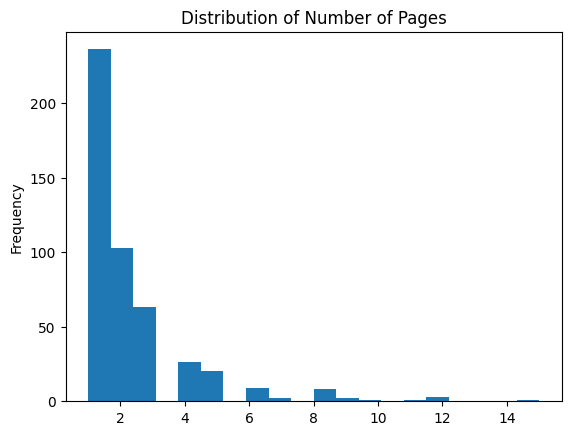

In [6]:
import pandas as pd

# Plot the distribution of the number of pages per dialogue.
df = pd.DataFrame([len(d) for d in dialogues], columns=["num_pages"])
df["num_pages"].plot(kind="hist", bins=20, title="Distribution of Number of Pages");

## Extract dialogues one by one

In [7]:
import os
from google import genai
from dotenv import load_dotenv

load_dotenv()
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

In [8]:
# With structured output.
import json
import time
from dataclasses import dataclass
import PIL.Image
from PIL.ImageFile import ImageFile
from google.genai import types
from google.genai.errors import ClientError, ServerError
from pydantic import BaseModel, Field


class Bubble(BaseModel):
    character: str = Field(description="Name of the character speaking in the bubble")
    text: str = Field(description="Text of the speech bubble")
    probability: int = Field(description="Probability of the attribution (0-5)")


class Response(BaseModel):
    dialogues: list[Bubble]


@dataclass
class ExtractedDialogue:
    character: str
    text: str
    probability: int

    def to_dict(self):
        return {
            "character": self.character,
            "text": self.text,
            "probability": self.probability,
        }

    def to_json(self):
        return json.dumps(self.to_dict())


prompt = """You are a comic book dialogue extractor. Given a comic book page image, extract all speech bubbles and assign each one to the character who is speaking. Convert capitalization to normal case. Do not translate the text, report it as is.

If a speaker's name is unclear, try to describe them briefly (e.g., "Masked man", "Woman with red hair").

Only include spoken dialogue from speech bubbles — skip narration boxes, sound effects, or other text. Ensure correct attribution based on visual clues such as tail direction, proximity, character expressions, style of the bubble and overall dialogue context.
Notable characters in this comic are (the list is not exhaustive):
- Paperinik (PK): A superhero alter ego of Donald Duck, known for his intelligence and resourcefulness.
- Donald Duck: The classic Disney character.
- Uno: has a duck-like appearance, inside a sphere that appears to be made of a bright green gelatinous substance, with small bubbles. It has a short, rounded beak, large, black eyes without defined pupils.
- Everett Ducklair: A duck with a large head and brown hair, usually with a serious expression and wearing a robe-like outfit.

For character attribution, also output the probability of the attribution in parentheses, from 0 to 5. Assign points based on the following criteria:
- One point if the character is clearly visible in the image and their name is known.
- One point if the speech bubble tail is pointing to the character.
- One point if the name of the character is known from the context of the dialogue.
- One point if the style of the bubble is consistent within the page.
- One point if the attribution is consistent with the overall dialogue context.

If there are multiple bubbles in the same frame, it's likely that different characters are speaking, even if one is not visible.
"""


def parse_dialogue(image: ImageFile | str) -> list[ExtractedDialogue]:
    if isinstance(image, str):
        image = PIL.Image.open(image)

    count = 0
    while True:
        try:
            response = client.models.generate_content(
                model=model_name,
                config=types.GenerateContentConfig(
                    max_output_tokens=65536,
                    response_mime_type="application/json",
                    response_schema=Response.model_json_schema(),
                    thinking_config=types.ThinkingConfig(
                        thinking_budget=thinking_budget
                    ),
                ),
                contents=[prompt, image],  # type: ignore
            )
            break

        except ClientError as e:
            if e.code != 429 or count > 3:
                raise
            print(f"Rate limit exceeded: {e}, retrying in 30 seconds...")
            time.sleep(30)
            count += 1

        except ServerError as e:
            if count > 3:
                raise
            print(f"Server error: {e}, retrying in 30 seconds...")
            time.sleep(30)
            count += 1

    if not response.text:
        raise ValueError("Response is empty")
    # Parse the response
    parsed = json.loads(response.text)
    return [ExtractedDialogue(**bubble) for bubble in parsed["dialogues"]]

In [9]:
# Test the function.
parse_dialogue(dialogues[0][0])

[ExtractedDialogue(character='PK', text='Hai paura di affrontarmi? Fatti vedere!', probability=3),
 ExtractedDialogue(character='PK', text='Veramente, mi stai già guardando!', probability=3),
 ExtractedDialogue(character='Uno', text='Io sono questo edificio!', probability=5),
 ExtractedDialogue(character='Uno', text='Ma se proprio hai bisogno di un volto a cui rivolgerti... Ecco!', probability=5),
 ExtractedDialogue(character='PK', text='Glom! Penso di averne viste abbastanza, per una sola notte!', probability=3),
 ExtractedDialogue(character='Donald Duck', text='Facciamoci coraggio!', probability=3),
 ExtractedDialogue(character='PK', text='Non so cosa tu sia, ma hai di fronte Paper-nik!', probability=4),
 ExtractedDialogue(character='Uno', text='Piacere! Io sono Uno!', probability=5),
 ExtractedDialogue(character='Donald Duck', text='Uno, eh? Dove hai lasciato gli altri?', probability=3),
 ExtractedDialogue(character='PK', text="Groan! Che battutaccia! E' terribile!", probability=3)]

In [10]:
import json
import hashlib

# For each page, extract the dialogues multiple times and save them together.


def extract_page(pages: list[str], pkna: str, out_prefix: str) -> None:
    for i, page in enumerate(pages):
        out_path = f"{out_prefix}-{i}.json"
        if os.path.exists(out_path):
            print(f"File {out_path} already exists, skipping.")
            continue

        res = {
            "model": model_name,
            "prompt_version": hashlib.sha1(prompt.encode("utf-8")).hexdigest()[:8],
            "pkna": pkna,
            "page": page,
            "takes": [],
        }
        try:
            for _ in range(num_samples):
                res["takes"].append(
                    {
                        "dialogue": [d.to_dict() for d in parse_dialogue(page)],
                    }
                )

        except Exception as e:
            # Save a partial result if an error occurs
            print(f"Error processing page {page}: {e}")
            with open(out_path.replace(".json", ".part.json"), "w") as f:
                json.dump(res, f, indent=2, ensure_ascii=False)
            continue

        with open(out_path, "w") as f:
            json.dump(res, f, indent=2, ensure_ascii=False)

In [11]:
def parse_name(page: str) -> tuple[str, str]:
    match = re.search(r"input/pkna/pkna-([^/]+).*?(\d+)\.jpe?g$", page)
    if not match:
        raise ValueError(f"Invalid page name: {page}")
    pkna = match.group(1)
    id = match.group(2)
    return pkna, id


[parse_name(page) for page in dialogues[1]], dialogues[1]

([('0', '040'), ('0', '041'), ('0', '042'), ('0', '043'), ('0', '044')],
 ['input/pkna/pkna-0/pkna-0-040.jpg',
  'input/pkna/pkna-0/pkna-0-041.jpg',
  'input/pkna/pkna-0/pkna-0-042.jpg',
  'input/pkna/pkna-0/pkna-0-043.jpg',
  'input/pkna/pkna-0/pkna-0-044.jpg'])

In [13]:
import tqdm

for dialogue in tqdm.tqdm(dialogues, desc="Processing dialogues..."):
    pkna, id = parse_name(dialogue[0])
    out_prefix = f"output/dialogues/pkna-{pkna}-conv-{id}"
    extract_page(dialogue, pkna, out_prefix)

Processing dialogues...:   0%|          | 0/475 [00:00<?, ?it/s]

File output/dialogues/pkna-0-conv-029-0.json already exists, skipping.
File output/dialogues/pkna-0-conv-029-1.json already exists, skipping.
File output/dialogues/pkna-0-conv-029-2.json already exists, skipping.
File output/dialogues/pkna-0-conv-029-3.json already exists, skipping.
File output/dialogues/pkna-0-conv-029-4.json already exists, skipping.
File output/dialogues/pkna-0-conv-029-5.json already exists, skipping.
File output/dialogues/pkna-0-conv-029-6.json already exists, skipping.
File output/dialogues/pkna-0-conv-029-7.json already exists, skipping.
File output/dialogues/pkna-0-conv-040-0.json already exists, skipping.
File output/dialogues/pkna-0-conv-040-1.json already exists, skipping.
File output/dialogues/pkna-0-conv-040-2.json already exists, skipping.
File output/dialogues/pkna-0-conv-040-3.json already exists, skipping.
File output/dialogues/pkna-0-conv-040-4.json already exists, skipping.
File output/dialogues/pkna-0-conv-046-0.json already exists, skipping.
File o

Processing dialogues...:  85%|████████▍ | 402/475 [00:55<00:10,  7.20it/s]

File output/dialogues/pkna-41-conv-049-0.json already exists, skipping.
File output/dialogues/pkna-41-conv-056-0.json already exists, skipping.
File output/dialogues/pkna-41-conv-056-1.json already exists, skipping.
File output/dialogues/pkna-41-conv-056-2.json already exists, skipping.


Processing dialogues...: 100%|██████████| 475/475 [01:57<00:00,  4.05it/s]

File output/dialogues/pkna-42-conv-16-0.json already exists, skipping.
File output/dialogues/pkna-42-conv-16-1.json already exists, skipping.
File output/dialogues/pkna-42-conv-25-0.json already exists, skipping.
File output/dialogues/pkna-42-conv-25-1.json already exists, skipping.
File output/dialogues/pkna-42-conv-25-2.json already exists, skipping.
File output/dialogues/pkna-42-conv-32-0.json already exists, skipping.
File output/dialogues/pkna-42-conv-32-1.json already exists, skipping.
File output/dialogues/pkna-42-conv-37-0.json already exists, skipping.
File output/dialogues/pkna-42-conv-37-1.json already exists, skipping.
File output/dialogues/pkna-42-conv-37-2.json already exists, skipping.
File output/dialogues/pkna-42-conv-43-0.json already exists, skipping.
File output/dialogues/pkna-42-conv-52-0.json already exists, skipping.
File output/dialogues/pkna-42-conv-55-0.json already exists, skipping.
File output/dialogues/pkna-42-conv-55-1.json already exists, skipping.
File o